# Constraining SLD: Bilayer (RefNX)

In some cases, we may want to constrain sld parameters via the integrals of layers in the `vfp`. This is especially useful when attempting to constrain the amount of material in one layer with the amount of material in a second layer.

In this example, we show how to use the `sld_constraint` parameter that can be supplied to `vfp.VFP`, `vfp.refnxVFP` and `vfp.refl1dVFP` to achieve such a constraint.

In [3]:
import numpy as np
import pathlib
import os
import matplotlib.pyplot as plt
import periodictable

from refnx.analysis import GlobalObjective, Parameter, Objective, CurveFitter
from refnx.reflect import ReflectModel, SLD
from refnx.dataset import ReflectDataset

import vfp

## A contrived example

We'll build a model where we have a substrate (silicon, with a silicon oxide layer) submerged in a water, with an adsorbed bilayer (e.g. lipid or surfactant). We *could* model the adsorbed material as layers containing the average of head and tail portions, but we can build a more informed model by considering the head and tail portions separately but with constraints to conserve the number of molecules across the head-tail pairing. An overview of the structure looks like this:

    Si | SiOx | Inner head | Inner tail | Outer tail | Outer head | Water

We've measured three contrasts of
- $\mathrm{D}_{2}\mathrm{O}$ + h-surfactant
- $\mathrm{H}_{2}\mathrm{O}$ + h-surfactant 
- $\mathrm{D}_{2}\mathrm{O}$ + tail-deuterated surfactant

### Head layer
We'll model the inner layer as containing surfactant head groups and some water, so the SLD of the inner layer is
$$\mathrm{SLD} = \mathrm{SLD}_{\mathrm{w}} * \phi_{\mathrm{w}} + \mathrm{SLD}_{\mathrm{h}} * \phi_{\mathrm{h}},$$
where $\mathrm{w}$ and $\mathrm{h}$ denote water and head group in the layer, and $\phi$ denotes their respective volume fractions in the layer. The sum of the volume fractions must add up to one, i.e $\sum_{j}{\phi_{j}} = 1$.

These parameters can all be specified relatively simply without any additional constraints outside of the flexibility provided by `refnx` or `refl1d`.

### Tail layer
An equivalent expression can be written for the tail layer
$$\mathrm{SLD} = \mathrm{SLD}_{\mathrm{w}}*\phi_{\mathrm{w}} + \mathrm{SLD}_{\mathrm{t}}*\phi_{\mathrm{t}},$$
where $\mathrm{t}$ denotes the surfactant tail group in the layer. Again $\sum_{j}*{\phi_{j}}=1$.

We assume that the water component described is a coverage parameter and is common across a head-tail pair. There may also be additional water molecules associated with the head (or tail) groups but this should be included in the head part ($\mathrm{SLD}_{\mathrm{h}}$).

## Conserving the number of surfactant molecules

The surface excess (number of units per unit area), $\Gamma$, of head groups and tail groups in a given layer must be equal to ensure a monolayer, i.e , $\Gamma_\mathrm{t, in} = \Gamma_\mathrm{h, in}$. The surface excess of a material $m$ in layer $j$ can be parameterised as 

$$ \Gamma_{m} = \phi_{m, j}\frac{\mathrm{SLD}_{m}}{b_{m}N_{\mathrm{A}}}\int{\Phi_{j}\left(z\right) \mathrm{d}z},$$

where $b_{m}$ is the scattering length of the material, $N_{\mathrm{A}}$ is Avogadro's constant and $\Phi_{j}\left(z\right)$ is the volume fraction profile of the $j\text{th}$ layer.

Therefore we can constrain $\phi_{\mathrm{t}}$ to be a function of $\phi_{\mathrm{h}}$ over the Head and Tail paired layers

$$
\begin{aligned}
\phi_{\mathrm{t}} \frac{\mathrm{SLD}_{\mathrm{t}}}{b_{\mathrm{t}}N_{\mathrm{A}}}\int{\Phi_{\mathrm{Tail}}\left(z\right) \mathrm{d}z} &= \phi_{\mathrm{h}}\frac{\mathrm{SLD}_{\mathrm{h}}}{b_{\mathrm{h}}N_{\mathrm{A}}}\int{\Phi_{\mathrm{Head}}\left(z\right) \mathrm{d}z} \\
\phi_{\mathrm{t}} &= \phi_{\mathrm{h}}\frac{\mathrm{SLD}_{\mathrm{h}}b_{\mathrm{t}}}{b_{\mathrm{h}}\mathrm{SLD}_{\mathrm{t}}}\frac{\int{\Phi_{\mathrm{Head}}\left(z\right) \mathrm{d}z}}{\int{\Phi_{\mathrm{Tail}}\left(z\right) \mathrm{d}z}}
\end{aligned}
$$

This expression is separately applied to the inner and outer leaflets.

Let's set up some refnx SLDs objects.

## Setup the constraint as a class:

In [4]:
class SLDConstraint:
    """
    Class with two methods that are used by the VFP.
    `layer_choices` returns the indices of the layers that we'll constrain together.
    '__call__' Uses the  a function that   
    """
    def __init__(self, required_pars: dict[float]):
        self.required_pars = required_pars
        
    def layer_choices(self) -> list[int]:
        return [2, 3, 4, 5]
        
    def __call__(self, layer_integrals: list[float]) -> tuple[list[int], list[float]]:
        lay2_int, lay3_int, lay4_int, lay5_int = layer_integrals
        
        surf_inner_head_vf, surf_inner_head_sld, surf_inner_tail_sld, b_surf_inner_head, b_surf_inner_tail, surf_outer_head_vf, surf_outer_head_sld, surf_outer_tail_sld, b_surf_outer_head, b_surf_outer_tail, water_sld = map(
            self.required_pars.get,
            ['surf_inner_head_vf', 
             'surf_inner_head_sld',
             'surf_inner_tail_sld',
             'b_surf_inner_head',
             'b_surf_inner_tail',
             'surf_outer_head_vf',
             'surf_outer_head_sld',
             'surf_outer_tail_sld',
             'b_surf_outer_head',
             'b_surf_outer_tail', 
             'water_sld'
             ]
        )
        
        # using the integrals, constrain the volume fraction of the tail
        surf_tail_vf_inner = (surf_inner_head_vf
                    * ((surf_inner_head_sld * b_surf_inner_tail) / (b_surf_inner_head * surf_inner_tail_sld)) 
                    * (lay2_int / lay3_int)
        )
        
        surf_tail_vf_outer = (surf_outer_head_vf
                    * ((surf_outer_head_sld * b_surf_outer_tail) / (b_surf_outer_head * surf_outer_tail_sld)) 
                    * (lay5_int / lay4_int)
        )
        
        inner_water_vf = 1 - (surf_tail_vf_inner)
        outer_water_vf = 1 - (surf_tail_vf_outer)
        
        # now we have outer_water_vf, we can calculate the true sld of the outer layer:
        layer_idx = [3, 4] # outer layer sld index
        altered_sld = [
            (inner_water_vf*water_sld + surf_tail_vf_inner*surf_inner_tail_sld),
            (outer_water_vf*water_sld + surf_tail_vf_outer*surf_outer_tail_sld)
        ]
        
        return layer_idx, altered_sld

## Breakdown of the `__call__` method above

The call method of `SLDConstraint` takes a list of floats, which are the integrals of the requested layers from `SLDConstraint.layer_choices`. These are passed to `SLDConstraint` by `vfp`. 

Using these integral values with the appropriate parameters (these will be passed to `SLDConstraint` when we initialise it), we calculate the volume fraction of the tail group for each leaflet. As we now know the head group volume fraction, and the water volume fraction can be determined. This means we can calcluate the sld of the tail layer with this constraint.

To update (possibly multiple) sld values in `vfp`, we return the layer indices and sld values in separate lists, and `vfp` will update the sld values for the layers specified by their indices.  

## Load test data:

In [5]:
dataset_dir = pathlib.Path(vfp.__path__[0]).parents[1] / 'docs'

d2o_data = ReflectDataset(dataset_dir / "Bilayer_constraint_testdata_d2o.txt")
h2o_data = ReflectDataset(dataset_dir / "Bilayer_constraint_testdata_h2o.txt")
d2o_dtails_data = ReflectDataset(dataset_dir / "Bilayer_constraint_testdata_d2o_dtails.txt")


## Setup a model to test the constraints:

In [6]:
# Describe a dummy surfactant molecule:

number_density = (853 / ((periodictable.C.mass * 16 + periodictable.H.mass* 32 + periodictable.O.mass*2)*1660.854))
print(f'number density = {number_density:.3e} Å^{-3}')

b_head = periodictable.C.neutron.b_c + 2*periodictable.O.neutron.b_c + periodictable.H.neutron.b_c

b_htail = 15*periodictable.C.neutron.b_c + 31*periodictable.H.neutron.b_c
b_dtail = 15*periodictable.C.neutron.b_c + 31*periodictable.D.neutron.b_c

b_full_d = periodictable.C.neutron.b_c * 16 + periodictable.H.neutron.b_c + 31*periodictable.D.neutron.b_c + periodictable.O.neutron.b_c*2
b_full_h = periodictable.C.neutron.b_c * 16 + periodictable.H.neutron.b_c + 31*periodictable.H.neutron.b_c + periodictable.O.neutron.b_c*2

print(f'b head = {b_head*1E-5:.3e} Å')
print(f'b h-tail = {b_htail*1E-5:.3e} Å')
print(f'b d-tail = {b_dtail*1E-5:.3e} Å')
print(f'b full d = {b_full_d*1E-5:.3e} Å = b head + b dtail = {1E-5 * (b_head + b_dtail):.3e} Å')
print(f'b full h = {b_full_h*1E-5:.3e} Å = b head + b htail = {1E-5 * (b_head + b_htail):.3e} Å')


print(f'sld of head = {number_density*b_head*1E-5*1E6:.3e} Å^{-2} x 10^-6')

print(f'sld of htail = {number_density*b_htail*1E-5*1E6:.3e} Å^{-2} x 10^-6')
print(f'sld of dtail = {number_density*b_dtail*1E-5*1E6:.3e} Å^{-2} x 10^-6')

print(f'sld of full h = {number_density*b_full_h*1E-5*1E6:.3e} Å^{-2} x 10^-6')
print(f'sld of full d = {number_density*b_full_d*1E-5*1E6:.3e} Å^{-2} x 10^-6')

number density = 2.003e-03 Å^-3
b head = 1.451e-04 Å
b h-tail = -1.626e-04 Å
b d-tail = 3.064e-03 Å
b full d = 3.209e-03 Å = b head + b dtail = 3.209e-03 Å
b full h = -1.746e-05 Å = b head + b htail = -1.746e-05 Å
sld of head = 2.907e-01 Å^-2 x 10^-6
sld of htail = -3.257e-01 Å^-2 x 10^-6
sld of dtail = 6.137e+00 Å^-2 x 10^-6
sld of full h = -3.497e-02 Å^-2 x 10^-6
sld of full d = 6.428e+00 Å^-2 x 10^-6


In [7]:
# Define the SLD / materials used in the model:

Si = SLD(2.07, name='Si')
SiO2 = SLD(3.47, name='SiO2')
surf_head_inner = SLD(0.291, name='surf_head_inner')
surf_h_tail = SLD(-0.326, name='surf_h-tail')
surf_d_tail = SLD(6.137, name='surf_h-tail')
surf_head_outer = SLD(0.291, name='surf_head_outer')
d2o = SLD(6.37, name='d2o')
h2o = SLD(-0.54, name='h2o')

In [8]:
# Create parameters for the parameters we will vary (i.e. the thickness, roughness and volume fractions:

sio2_thickness = Parameter(20, name='sio2_thickness', vary=True, bounds=(10, 30))
inner_head_thickness = Parameter(5, name='inner_head_thickness', vary=True, bounds=(1, 7))
outer_head_thickness = Parameter(5, name='outer_head_thickness', vary=True, bounds=(1, 7))
inner_tail_thickness = Parameter(10, name='inner_tail_thickness', vary=True, bounds=(8, 20))
outer_tail_thickness = Parameter(10, name='outer_tail_thickness', vary=True, bounds=(8, 20))

si_sio2_roughness = Parameter(1, name='si_sio2_roughness', vary=True, bounds=(1, 5))
sio2_inner_roughness = Parameter(1, name='sio2_inner_roughness', vary=True, bounds=(1, 6))
inner_outer_roughness = Parameter(1, name='inner_outer_roughness', vary=True, bounds=(1, 5))
outer_solv_roughness = Parameter(1, name='outer_solv_roughness', vary=True, bounds=(1, 6))

surf_inner_vf = Parameter(0.5, name='surf_inner_vf', vary=True, bounds=(0, 1))
surf_outer_vf = Parameter(0.5, name='surf_outer_vf', vary=True, bounds=(0, 1))

# Specify the b values for the head and tail groups. These can be parameters or calculated.
b_heads_inner=b_head
b_heads_outer=b_head
b_htails=b_htail
b_dtails=b_dtail

In [9]:
# Assemble lists in the structure order for our thickness, roughness and slds

thicknesses = (0, sio2_thickness, inner_head_thickness, inner_tail_thickness, outer_tail_thickness, outer_head_thickness)
roughnesses = (si_sio2_roughness, sio2_inner_roughness, inner_outer_roughness,inner_outer_roughness,inner_outer_roughness, outer_solv_roughness)

d2o_slds = [Si.real,
               SiO2.real,
               surf_inner_vf * surf_head_inner.real + (1-surf_inner_vf) * d2o.real,
               1, # this will be updated by the vfp.
               1, # this will be updated by the vfp.
               surf_outer_vf * surf_head_outer.real + (1-surf_outer_vf) * d2o.real,
               d2o.real]

h2o_slds = [Si.real,
               SiO2.real,
               surf_inner_vf * surf_head_inner.real + (1-surf_inner_vf) * h2o.real,
               1, # this will be updated by the vfp.
               1, # this will be updated by the vfp.
               surf_outer_vf * surf_head_outer.real + (1-surf_outer_vf) * h2o.real,
               h2o.real]

d2o_slds_dtail = [Si.real,
               SiO2.real,
               surf_inner_vf * surf_head_inner.real + (1-surf_inner_vf) * d2o.real,
               1, # this will be updated by the vfp.
               1, # this will be updated by the vfp.
               surf_outer_vf * surf_head_outer.real + (1-surf_outer_vf) * d2o.real,
               d2o.real]

In [10]:
# Define the dictionaries we use for the constraints

# D2O is defined first
d2o_constraint_ps = dict(
        surf_inner_head_vf=surf_inner_vf,
        surf_inner_head_sld=surf_head_inner.real,
        surf_inner_tail_sld=surf_h_tail.real,
        b_surf_inner_head=b_heads_inner,
        b_surf_inner_tail=b_htails, 
        surf_outer_head_vf=surf_outer_vf,
        surf_outer_head_sld=surf_head_outer.real,
        surf_outer_tail_sld=surf_h_tail.real,
        b_surf_outer_head=b_heads_outer,
        b_surf_outer_tail=b_htails,
        water_sld=d2o.real
)

# Then we can make copies of this and overwrite the per-contrast parameters

h2o_constraint_ps = d2o_constraint_ps.copy()
h2o_constraint_ps['water_sld']=h2o.real

d2o_dtail_constraint_ps = d2o_constraint_ps.copy()
d2o_dtail_constraint_ps['surf_inner_tail_sld']=surf_d_tail.real
d2o_dtail_constraint_ps['surf_outer_tail_sld']=surf_d_tail.real
d2o_dtail_constraint_ps['b_surf_outer_tail']=b_dtails
d2o_dtail_constraint_ps['b_surf_inner_tail']=b_dtails



In [11]:
# Assemble these into the VFP objects for each contrast:

d2o_vfp = vfp.refnxVFP(nslds=d2o_slds,
                     thicknesses=thicknesses,
                     roughnesses=roughnesses,
                     sld_constraint=SLDConstraint(required_pars=d2o_constraint_ps))

h2o_vfp = vfp.refnxVFP(nslds=h2o_slds,
                     thicknesses=thicknesses,
                     roughnesses=roughnesses,
                     sld_constraint=SLDConstraint(required_pars=h2o_constraint_ps))

d2o_dtails_vfp = vfp.refnxVFP(nslds=d2o_slds_dtail,
                     thicknesses=thicknesses,
                     roughnesses=roughnesses,
                     sld_constraint=SLDConstraint(required_pars=d2o_dtail_constraint_ps))

### We can see what the starting guess looks like

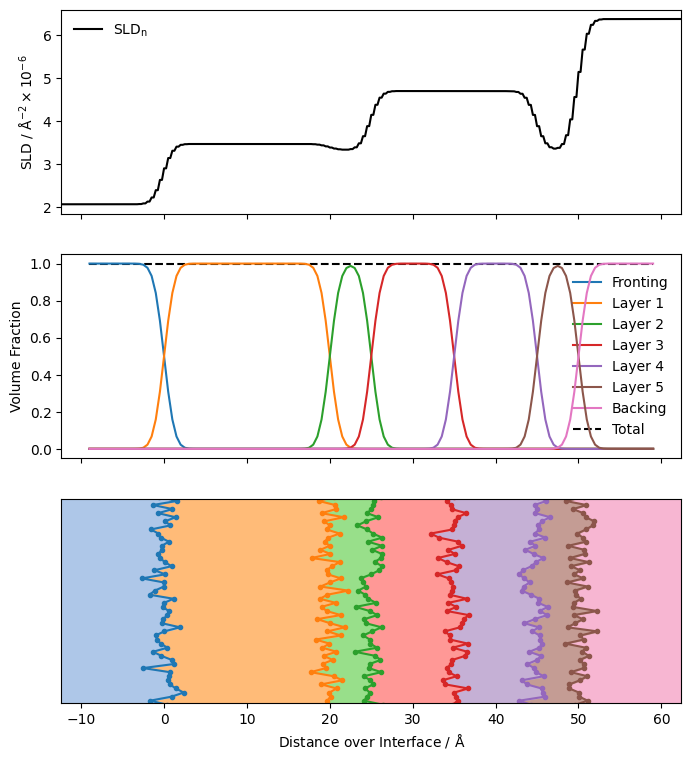

In [12]:
## Note: this might need updating with new plotting features.
d2o_vfp.plot()
plt.show()

## Setup the Objective to Fit:

In [13]:
# Define our structures

d2o_vfp_struc = Si | d2o_vfp | d2o
h2o_vfp_struc = Si | h2o_vfp | h2o
d2o_dtails_vfp_struc = Si | d2o_dtails_vfp | d2o

In [14]:
# Allow background and scaling-factors / intensities to vary

d2o_int = Parameter(1, name='d2o_int', vary=True, bounds=(0.9, 1.1))
d2o_bkg = Parameter(1e-6, name='d2o_bkg', vary=True, bounds=(1e-7, 1e-4))

h2o_int = Parameter(1, name='h2o_int', vary=True, bounds=(0.9, 1.1))
h2o_bkg = Parameter(1e-6, name='h2o_bkg', vary=True, bounds=(1e-7, 1e-4))

d2o_dt_int = Parameter(1, name='d2o_dt_int', vary=True, bounds=(0.9, 1.1))
d2o_dt_bkg = Parameter(1e-6, name='d2o_dt_bkg', vary=True, bounds=(1e-7, 1e-4))

In [15]:
# Define our models

d2o_model = ReflectModel(structure=d2o_vfp_struc, scale=d2o_int, bkg=d2o_bkg, dq=3*2.355)
h2o_model = ReflectModel(structure=h2o_vfp_struc, scale=h2o_int, bkg=h2o_bkg, dq=3*2.355)
d2o_dt_model = ReflectModel(structure=d2o_dtails_vfp_struc, scale=d2o_dt_int, bkg=d2o_dt_bkg, dq=3*2.355)

In [16]:
# Link the models and data into our Objectives

d2o_obj = Objective(model=d2o_model, data=d2o_data)
h2o_obj = Objective(model=h2o_model, data=h2o_data)
d2o_dt_obj = Objective(model=d2o_dt_model, data=d2o_dtails_data)
global_objective = GlobalObjective([d2o_obj, h2o_obj, d2o_dt_obj])

## Check the setup for the fit optimisation:

In [17]:
print(global_objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:   'd2o_int'   , value=1          , bounds=[0.9, 1.1]>
<Parameter:   'd2o_bkg'   , value=1e-06          , bounds=[1e-07, 0.0001]>
<Parameter:'sio2_thickness', value=20          , bounds=[10.0, 30.0]>
<Parameter:'inner_head_thickness', value=5          , bounds=[1.0, 7.0]>
<Parameter:'inner_tail_thickness', value=10          , bounds=[8.0, 20.0]>
<Parameter:'outer_tail_thickness', value=10          , bounds=[8.0, 20.0]>
<Parameter:'outer_head_thickness', value=5          , bounds=[1.0, 7.0]>
<Parameter:'si_sio2_roughness', value=1          , bounds=[1.0, 5.0]>
<Parameter:'sio2_inner_roughness', value=1          , bounds=[1.0, 6.0]>
<Parameter:'inner_outer_roughness', value=1          , bounds=[1.0, 5.0]>
<Parameter:'outer_solv_roughness', value=1          , bounds=[1.0, 6.0]>
<Parameter:'surf_inner_vf', value=0.5          , bounds=[0.0, 1.0]>
<Parameter:'surf_outer_vf'

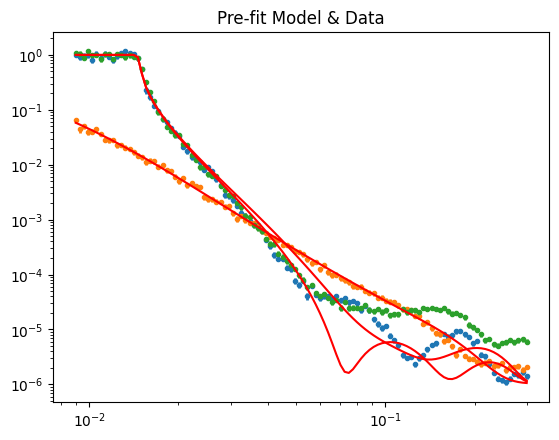

In [18]:
# Show the plot for the pre-fit state:
fig,ax=global_objective.plot()
plt.title("Pre-fit Model & Data")
plt.xscale('log')
plt.yscale('log')

## Fit the objective.

Differential evolution uses multiprocessing to parallelise the fit procedure. Unfortunately, the combination of windows + jupyter notebook doesn't make this easy. One way around is to define SLDConstraint class in a separate file and import here, but this doesn't really lend it self to an example! Another way around this is to use the `pathos` package in place of multiprocessing with `ProcessPool`. This can be installed via pip.

In [19]:
from pathos.pools import ProcessPool

pool = ProcessPool(nodes=4)
fitter = CurveFitter(objective=global_objective)
fitter.fit(method='differential_evolution', workers=pool.map)

# if not running on windows, just run the following:
# fitter = CurveFitter(objective=global_objective)
# fitter.fit(method='differential_evolution', workers=-1)

0it [00:00, ?it/s]/Users/r2i/Documents/VFP_desktop/VFP/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
-2858.5873840365616: : 64it [01:35,  1.49s/it]


             message: Optimization terminated successfully.
             success: True
                 fun: -2867.5499213636103
                   x: [ 1.056e+00  1.189e-06 ...  9.984e-01  5.383e-06]
                 nit: 64
                nfev: 17637
          population: [[ 1.056e+00  1.247e-06 ...  9.964e-01  5.204e-06]
                       [ 1.008e+00  9.968e-07 ...  9.466e-01  5.332e-06]
                       ...
                       [ 1.047e+00  1.151e-06 ...  9.684e-01  4.984e-06]
                       [ 1.022e+00  1.361e-06 ...  9.390e-01  5.353e-06]]
 population_energies: [-2.868e+03 -2.795e+03 ... -2.806e+03 -2.798e+03]
                 jac: [ 1.364e+01  6.318e+04 ...  6.900e+00 -2.096e+05]
               covar: [[ 2.520e-04 -4.485e-11 ...  7.189e-06  2.006e-10]
                       [-4.485e-11  2.982e-15 ...  4.384e-11  6.247e-16]
                       ...
                       [ 7.189e-06  4.384e-11 ...  2.333e-04  2.396e-10]
                       [ 2.006e-10  

## Look at the Fit Outcome:

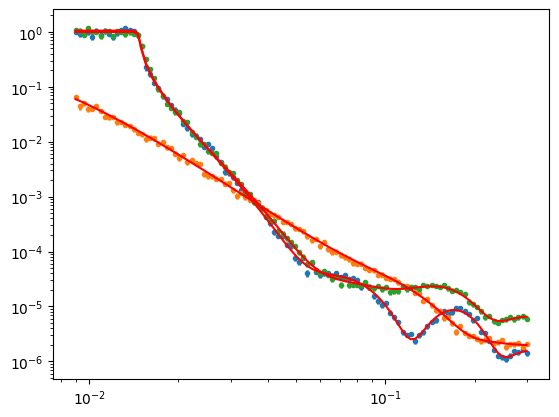

In [20]:
fig, ax = global_objective.plot()
plt.xscale('log')
plt.yscale('log')

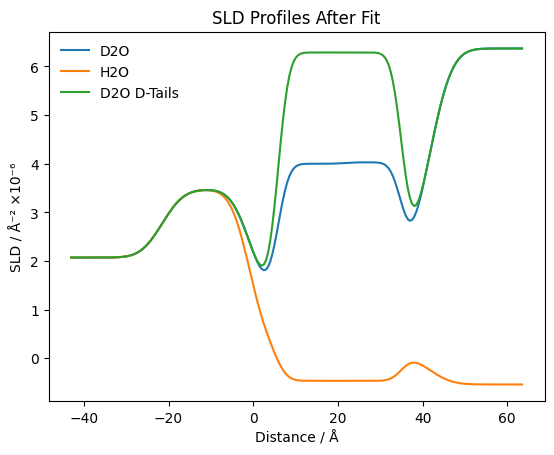

In [21]:
fig, ax = plt.subplots()
for vfp_obj, label in [(d2o_vfp, "D2O"), (h2o_vfp, "H2O"), (d2o_dtails_vfp, "D2O D-Tails")]:
    z, all_slds = vfp_obj.z_and_sld()
    ax.plot(z + vfp_obj.sld_offset(), all_slds[:, 0], label=label)  # sld_n
ax.set_ylabel("SLD / Å⁻² ×10⁻⁶")
ax.set_xlabel("Distance / Å")
ax.legend(frameon=False)
plt.title("SLD Profiles After Fit")
plt.show()


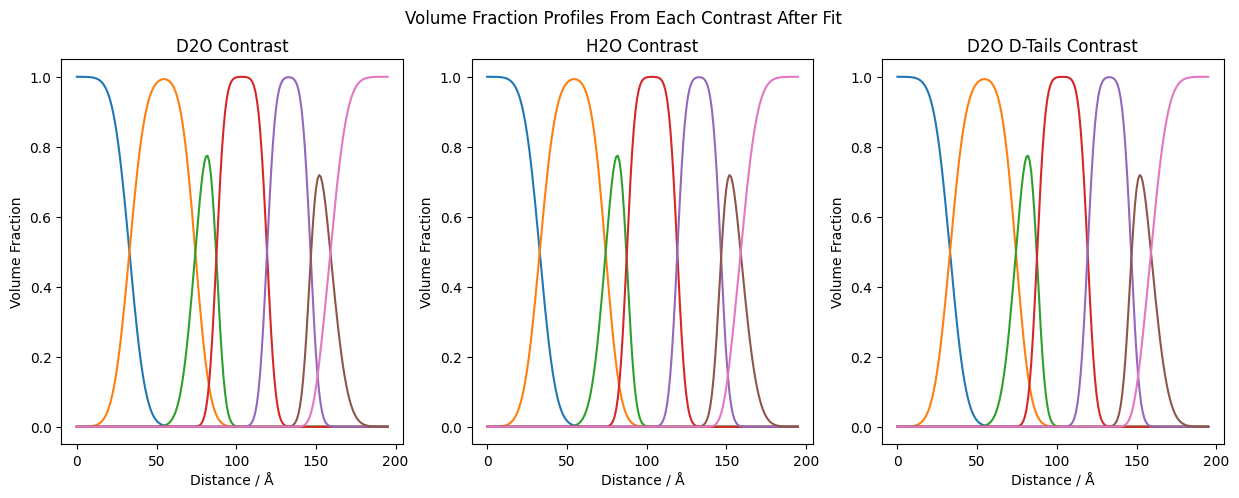

In [22]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
fig.suptitle("Volume Fraction Profiles From Each Contrast After Fit")
for idx, (vfp_obj, lbl) in enumerate([(d2o_vfp, "D2O"), (h2o_vfp, "H2O"), (d2o_dtails_vfp, "D2O D-Tails")]):
    for material in range(len(vfp_obj.vfs_for_display()[0])):
        ax[idx].plot(vfp_obj.vfs_for_display()[0][material])
    ax[idx].set_title(f"{lbl} Contrast")
    ax[idx].set_xlabel("Distance / Å")
    ax[idx].set_ylabel("Volume Fraction")

#d2o_vfp.vfs_for_display()[0]

This shows good agreement in the volume fractions for each component layer

In [23]:
print(global_objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:   'd2o_int'   , value=1.05601 +/- 0.0159, bounds=[0.9, 1.1]>
<Parameter:   'd2o_bkg'   , value=1.18891e-06 +/- 5.46e-08, bounds=[1e-07, 0.0001]>
<Parameter:'sio2_thickness', value=20.672 +/- 0.629, bounds=[10.0, 30.0]>
<Parameter:'inner_head_thickness', value=6.58471 +/- 0.856, bounds=[1.0, 7.0]>
<Parameter:'inner_tail_thickness', value=15.903 +/- 0.875, bounds=[8.0, 20.0]>
<Parameter:'outer_tail_thickness', value=13.6334 +/- 1.23 , bounds=[8.0, 20.0]>
<Parameter:'outer_head_thickness', value=6.2414 +/- 3.91 , bounds=[1.0, 7.0]>
<Parameter:'si_sio2_roughness', value=4.02729 +/- 1.34 , bounds=[1.0, 5.0]>
<Parameter:'sio2_inner_roughness', value=3.59617 +/- 0.901, bounds=[1.0, 6.0]>
<Parameter:'inner_outer_roughness', value=2.11245 +/- 0.718, bounds=[1.0, 5.0]>
<Parameter:'outer_solv_roughness', value=4.22025 +/- 1.89 , bounds=[1.0, 6.0]>
<Parameter:'surf_inner_vf', va

## Check the constraints on surface excess between contrasts has been achieved:

In [24]:
## Find vf from fit output
inner_vf = global_objective.varying_parameters()[11].value
outer_vf = global_objective.varying_parameters()[12].value
## SLDs are from original setup as don't vary in fit
inner_head_sld = surf_head_inner.real.value
outer_head_sld = surf_head_outer.real.value
htail_sld = surf_h_tail.real.value
dtail_sld = surf_d_tail.real.value

In [25]:
# Calculate the surface excesses from the fit output

from vfp.calc import integrate_vfp, init_demag

red_vfp, red_demag_vfp, idx, demag_arr = init_demag(
    d2o_vfp.tup_demag_locs,
    d2o_vfp.tup_demag_widths,
    d2o_vfp.tup_mslds,
    d2o_vfp.zeds,
    d2o_vfp._arrtotuple(d2o_vfp.vfp),
)

integrals = integrate_vfp(
    d2o_vfp.zeds,
    d2o_vfp.indices,
    d2o_vfp._arrtotuple(red_vfp),
    tuple([2, 3, 4, 5])
)


# calculate the vf from the parameters
surf_tail_vf_inner_h = (inner_vf * ((inner_head_sld * b_htails) / (b_heads_inner * htail_sld)) 
            * (integrals[0] / integrals[1])
)

surf_tail_vf_inner_d = (inner_vf * ((inner_head_sld * b_dtails) / (b_heads_inner * dtail_sld)) 
            * (integrals[0] / integrals[1])
)

surf_tail_vf_outer_h = (outer_vf * ((outer_head_sld * b_htails) / (b_heads_outer * htail_sld)) 
            * (integrals[3] / integrals[2])
)

surf_tail_vf_outer_d = (outer_vf * ((outer_head_sld * b_dtails) / (b_heads_outer * dtail_sld)) 
            * (integrals[3] / integrals[2])
)

print("-------------- Inner Comparison --------------")
print(f'Inner head surface excess = {(inner_vf * ((inner_head_sld * 1E-6) / (b_heads_inner*1E-5) * periodictable.constants.avogadro_number) * integrals[0]) / 1E20:.3e} mol m-2')
print(f'Inner tail surface excess from h = {(surf_tail_vf_inner_h * ((htail_sld * 1E-6) / (b_htails*1E-5) * periodictable.constants.avogadro_number) * integrals[1]) / 1E20:.3e} mol m-2')
print(f'Inner tail surface excess from d = {(surf_tail_vf_inner_d * ((dtail_sld * 1E-6) / (b_dtails*1E-5) * periodictable.constants.avogadro_number) * integrals[1]) / 1E20:.3e} mol m-2')
print("-------------- Outer Comparison --------------")
print(f'Outer head surface excess = {(outer_vf * ((outer_head_sld * 1E-6) / (b_heads_outer*1E-5) * periodictable.constants.avogadro_number) * integrals[3]) / 1E20:.3e} mol m-2')
print(f'Outer tail surface excess from h = {(surf_tail_vf_outer_h * ((htail_sld * 1E-6) / (b_htails*1E-5) * periodictable.constants.avogadro_number) * integrals[2]) / 1E20:.3e} mol m-2')
print(f'Outer tail surface excess from d = {(surf_tail_vf_outer_d * ((dtail_sld * 1E-6) / (b_dtails*1E-5) * periodictable.constants.avogadro_number) * integrals[2]) / 1E20:.3e} mol m-2')

-------------- Inner Comparison --------------
Inner head surface excess = 6.754e+01 mol m-2
Inner tail surface excess from h = 6.754e+01 mol m-2
Inner tail surface excess from d = 6.754e+01 mol m-2
-------------- Outer Comparison --------------
Outer head surface excess = 5.756e+01 mol m-2
Outer tail surface excess from h = 5.756e+01 mol m-2
Outer tail surface excess from d = 5.756e+01 mol m-2


### These show the surface excess has been maintained across the 3 contrasts - Success!